In [17]:
# Observations stats 2.1 to 2.3

In [45]:
from __future__ import annotations

from pathlib import Path
import logging
from datetime import datetime, timezone
import pandas as pd
import numpy as np

# =============================================================================
# CONFIG (edit if needed)
# =============================================================================
ROOT = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026")

# Inputs
MAIN_CSV = ROOT / "5_Total_Repo.csv"
EPISODES_CSV = ROOT / "2 - RQ2" / "Observations" / "List_Change_Episodes.csv"

# Output folder (and log file)
OUT_DIR = ROOT / "2 - RQ2" / "Supporting_Stat"
OUT_DIR.mkdir(parents=True, exist_ok=True)
LOG_PATH = OUT_DIR / "rq2_stat_generator.log"

# Paper cutoff
CUTOFF_ISO = "2025-08-10 23:59:59+00:00"

# RQ2 scope (paper: default branch first-parent strategy)
#RQ2_TIMELINE_SCOPE = "default_first_parent"
RQ2_TIMELINE_SCOPES = {"default_first_parent", "repo_wide"}  # include both for now


# 3-year bucket settings (chosen so you get a 2020–2022 bucket)
BUCKET_SIZE_YEARS = 3
BUCKET_ANCHOR_YEAR = 2020

CANON_STATES = ["Community", "Custom", "Mixed", "GMD", "ThirdParty"]
CANON_STYLES = ["Community", "Custom", "GMD", "ThirdParty"]

# =============================================================================
# Logging
# =============================================================================
def setup_logger() -> logging.Logger:
    logger = logging.getLogger("rq2")
    logger.setLevel(logging.INFO)
    logger.handlers.clear()

    fmt = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")

    sh = logging.StreamHandler()
    sh.setFormatter(fmt)
    logger.addHandler(sh)

    fh = logging.FileHandler(LOG_PATH, mode="w", encoding="utf-8")
    fh.setFormatter(fmt)
    logger.addHandler(fh)

    return logger

# =============================================================================
# Helpers
# =============================================================================
def find_col(df: pd.DataFrame, options: list[str]) -> str:
    low = {c.lower(): c for c in df.columns}
    for o in options:
        if o.lower() in low:
            return low[o.lower()]
    # substring fallback
    for o in options:
        for c in df.columns:
            if o.lower() in c.lower():
                return c
    raise KeyError(f"Could not find any of columns: {options}")

def parse_dt(x) -> pd.Timestamp:
    if x is None:
        return pd.NaT
    s = str(x).strip()
    if not s or s.lower() in {"nan", "nat", "none", "null"}:
        return pd.NaT
    s = s.replace("Z", "+00:00")
    return pd.to_datetime(s, utc=True, errors="coerce")

def normalize_token(x: str) -> str:
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return ""
    s = str(x).strip()
    if not s or s.lower() in {"nan", "none", "null"}:
        return ""

    low = s.lower().replace(" ", "").replace("-", "").replace("_", "")
    if low in {"community", "emucommunity", "emucommunity"} or "emucommunity" in low:
        return "Community"
    if low in {"custom", "emucustom"} or "emucustom" in low:
        return "Custom"
    if low in {"gmd", "emugmd"} or "emugmd" in low:
        return "GMD"
    if low == "mixed":
        return "Mixed"
    if "third" in low:
        return "ThirdParty"
    return s

def parse_styleset(cell) -> list[str]:
    if cell is None or (isinstance(cell, float) and np.isnan(cell)):
        return []
    s = str(cell).strip()
    if not s or s.lower() in {"nan", "none", "null"}:
        return []

    # tolerate list-like strings
    s2 = s.replace("[", "").replace("]", "").replace("'", "").replace('"', "")

    parts = [s2]
    for sep in ["||", "+", ",", ";"]:
        if sep in s2:
            parts = [p.strip() for p in s2.split(sep)]
            break

    styles = [normalize_token(p) for p in parts]
    styles = [st for st in styles if st and st != "Mixed"]
    styles = [st for st in styles if st in CANON_STYLES]
    return sorted(set(styles))

def state_from_styles(styles: list[str]) -> str:
    styles = [s for s in styles if s in CANON_STYLES]
    if not styles:
        return ""
    return "Mixed" if len(styles) >= 2 else styles[0]

def fmt_n_pct(n: int, N: int) -> str:
    pct = (100.0 * n / N) if N else 0.0
    return f"{n} ({pct:.1f}%)"

def banner(logger: logging.Logger, title: str) -> None:
    logger.info("")
    logger.info("=" * 88)
    logger.info(title)
    logger.info("=" * 88)

def make_3y_buckets(min_year: int, max_year: int,
                    anchor_year: int = BUCKET_ANCHOR_YEAR,
                    size: int = BUCKET_SIZE_YEARS) -> list[tuple[str, pd.Timestamp, pd.Timestamp]]:
    # choose a start year >= min_year that aligns to anchor_year modulo size (so we get 2020–2022)
    start_year = min_year
    while start_year % size != anchor_year % size:
        start_year += 1

    buckets = []
    y = start_year
    while y <= max_year:
        b_start = pd.Timestamp(datetime(y, 1, 1, tzinfo=timezone.utc))
        b_end = pd.Timestamp(datetime(y + size, 1, 1, tzinfo=timezone.utc))
        buckets.append((f"{y}-{y+size-1}", b_start, b_end))
        y += size
    return buckets

# =============================================================================
# Core prep: load + build retained episode traces + transitions
# =============================================================================
def load_and_prepare(logger: logging.Logger) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    cutoff_dt = pd.to_datetime(CUTOFF_ISO, utc=True, errors="coerce")

    # Read both inputs (as requested)
    repo_df = pd.read_csv(MAIN_CSV, low_memory=False)
    ep_df = pd.read_csv(EPISODES_CSV, low_memory=False)

    # Resolve required columns (tolerant)
    c_repo = find_col(ep_df, ["full_name", "repo", "repository", "repo_name"])
    c_scope = find_col(ep_df, ["timeline_scope"])
    c_start = find_col(ep_df, ["episode_start_utc", "start_utc", "episode_start"])
    c_end = find_col(ep_df, ["episode_end_utc", "end_utc", "episode_end"])
    c_idx = find_col(ep_df, ["episode_index", "index"])
    c_state = find_col(ep_df, ["episode_state_label", "state_label", "state"])
    c_styles = find_col(ep_df, ["episode_styleset", "styleset", "style_set"])
    c_active = find_col(ep_df, ["is_active_at_cutoff", "active_at_cutoff"])
    c_persist = find_col(ep_df, ["is_persistent_ge14d", "persistent_ge14d"])

    ep = ep_df.copy()
    ep["repo"] = ep[c_repo].astype(str).str.strip()

    ep["timeline_scope"] = ep[c_scope].astype(str).str.strip().str.lower()
    #ep = ep[ep["timeline_scope"] == RQ2_TIMELINE_SCOPE].copy()
    ep = ep[ep["timeline_scope"].isin(RQ2_TIMELINE_SCOPES)].copy()


    ep["start"] = ep[c_start].apply(parse_dt)
    ep["end"] = ep[c_end].apply(parse_dt)
    ep["episode_index"] = pd.to_numeric(ep[c_idx], errors="coerce")

    # ep["is_active_at_cutoff"] = ep[c_active].fillna(False).astype(bool)
    # ep["is_persistent_ge14d"] = ep[c_persist].fillna(False).astype(bool)
    def parse_flag(v) -> bool:
        s = str(v).strip().lower()
        return s in {"1", "true", "t", "yes", "y"}

    ep["is_active_at_cutoff"] = ep[c_active].apply(parse_flag)
    ep["is_persistent_ge14d"] = ep[c_persist].apply(parse_flag)


    # Retention rule (paper): keep if >=14d OR active at cutoff
    ep["retained"] = ep["is_persistent_ge14d"] | ep["is_active_at_cutoff"]
    ep = ep[ep["retained"]].copy()

    # Clip/patch ends
    ep.loc[ep["end"].isna() & ep["is_active_at_cutoff"], "end"] = cutoff_dt
    ep["end"] = ep["end"].fillna(cutoff_dt)
    ep["end"] = ep["end"].apply(lambda t: min(t, cutoff_dt) if pd.notna(t) else cutoff_dt)

    # Canonicalize state + styleset
    ep["styles"] = ep[c_styles].apply(parse_styleset)
    ep["state"] = ep[c_state].apply(normalize_token)
    ep.loc[ep["state"] == "", "state"] = ep["styles"].apply(state_from_styles)

    # Keep only canonical states
    ep = ep[ep["state"].isin(CANON_STATES)].copy()

    # Order episodes within repo
    ep = ep.sort_values(["repo", "start", "episode_index"], ascending=[True, True, True]).reset_index(drop=True)

    # Entry / current per repo (paper’s consistency check logic)
    g = ep.groupby("repo", sort=False)
    entry_state = g.first()["state"]

    def current_state(df: pd.DataFrame) -> str:
        active = df[df["is_active_at_cutoff"]]
        if len(active) > 0:
            return active.sort_values("start").iloc[-1]["state"]
        return df.sort_values("start").iloc[-1]["state"]

    current_state_series = g.apply(current_state)

    # Transitions (episode-to-episode)
    trans_rows = []
    for repo_id, df in ep.groupby("repo", sort=False):
        df2 = df.sort_values(["start", "episode_index"])
        states = df2["state"].tolist()
        starts = df2["start"].tolist()
        for i in range(len(states) - 1):
            trans_rows.append((repo_id, states[i], states[i + 1], starts[i + 1]))
    trans = pd.DataFrame(trans_rows, columns=["repo", "from_state", "to_state", "transition_start_utc"])

    # Quick context summary
    banner(logger, "RQ2 DATASET SUMMARY (after scope + retention)")
    N = ep["repo"].nunique()
    logger.info(f"Cutoff: {CUTOFF_ISO}")
#    logger.info(f"Timeline scope: {RQ2_TIMELINE_SCOPE}")
    logger.info(f"Timeline scopes: {sorted(RQ2_TIMELINE_SCOPES)}")

    logger.info(f"Repositories (N): {N}")
    logger.info(f"Retained episodes: {len(ep)}")
    logger.info(f"Transitions: {len(trans)}  (should equal episodes - repos = {len(ep)} - {N} = {len(ep)-N})")

    # Save supporting CSVs (optional but useful for archiving)
    ep.to_csv(OUT_DIR / "rq2_retained_episodes_default_first_parent.csv", index=False, encoding="utf-8")
    trans.to_csv(OUT_DIR / "rq2_transitions.csv", index=False, encoding="utf-8")

    # Also store entry/current per repo
    pd.DataFrame({"repo": entry_state.index, "entry_state": entry_state.values, "current_state": current_state_series.values}) \
      .to_csv(OUT_DIR / "rq2_entry_current_by_repo.csv", index=False, encoding="utf-8")

    # We return repo_df too (even if not used heavily), since you asked the script to read it
    repo_df.to_csv(OUT_DIR / "5_Total_Repo_copy_for_archive.csv", index=False, encoding="utf-8")

    return repo_df, ep, trans, entry_state, current_state_series

# =============================================================================
# Observation 2.1 stats
# =============================================================================
def observation_2_1(logger: logging.Logger, entry: pd.Series, current: pd.Series, trans: pd.DataFrame) -> None:
    banner(logger, "Observation 2.1 — Entry vs Current + State Machine (Custom → Community dominance)")

    N = int(entry.shape[0])

    def headline_bucket(s: str) -> str:
        return s if s in {"Community", "Custom"} else "Other (Mixed+GMD+ThirdParty)"

    entry_head = entry.map(headline_bucket)
    curr_head = current.map(headline_bucket)

    tab = pd.DataFrame({
        "State (headline)": ["Community", "Custom", "Other (Mixed+GMD+ThirdParty)"],
        "Entry": [
            fmt_n_pct(int((entry_head == "Community").sum()), N),
            fmt_n_pct(int((entry_head == "Custom").sum()), N),
            fmt_n_pct(int((entry_head == "Other (Mixed+GMD+ThirdParty)").sum()), N),
        ],
        "Current": [
            fmt_n_pct(int((curr_head == "Community").sum()), N),
            fmt_n_pct(int((curr_head == "Custom").sum()), N),
            fmt_n_pct(int((curr_head == "Other (Mixed+GMD+ThirdParty)").sum()), N),
        ],
    })

    logger.info("Table: Entry vs Current (headline states)")
    logger.info("\n" + tab.to_string(index=False))

    # State machine / transitions
    T = len(trans)
    cc = trans[(trans["from_state"] == "Custom") & (trans["to_state"] == "Community")]
    logger.info(f"Total transitions: {T}")
    logger.info(f"Dominant transition Custom→Community: {len(cc)}/{T} ({(len(cc)/T*100 if T else 0):.1f}%)")

    # Top-2 outgoing transitions per state (as used for the figure caption)
    logger.info("Top-2 outgoing transitions per state (p, n):")
    if T == 0:
        logger.info("  (No transitions)")
        return

    out = trans.groupby(["from_state", "to_state"]).size().reset_index(name="n")
    for from_state in CANON_STATES:
        sub = out[out["from_state"] == from_state].copy()
        if sub.empty:
            continue
        denom = sub["n"].sum()
        sub = sub.sort_values(["n", "to_state"], ascending=[False, True]).head(2)
        for _, r in sub.iterrows():
            p = r["n"] / denom if denom else 0.0
            logger.info(f"  {from_state} → {r['to_state']}: p={p:.3f}, n={int(r['n'])}")

    # Save transition counts
    out.sort_values(["n", "from_state", "to_state"], ascending=[False, True, True]) \
       .to_csv(OUT_DIR / "obs2_1_transition_counts.csv", index=False, encoding="utf-8")

# =============================================================================
# Observation 2.2 stats
# =============================================================================
def observation_2_2(logger: logging.Logger, ep: pd.DataFrame, trans: pd.DataFrame) -> None:
    banner(logger, "Observation 2.2 — Rarity of Change + Temporal Clustering (2020–2022) + 3-year Buckets")

    N = int(ep["repo"].nunique())
    per_repo_k = ep.groupby("repo").size()
    n_one = int((per_repo_k == 1).sum())
    n_migrate = int((per_repo_k > 1).sum())
    k_max = int(per_repo_k.max())

    logger.info(f"Repos with exactly 1 retained episode (no transition): {fmt_n_pct(n_one, N)}")
    logger.info(f"Repos with ≥1 transition: {fmt_n_pct(n_migrate, N)}")
    logger.info(f"Max episodes observed in any repo: {k_max}")

    # Custom→Community transitions by year (start of destination episode)
    cc = trans[(trans["from_state"] == "Custom") & (trans["to_state"] == "Community")].copy()
    cc["year"] = cc["transition_start_utc"].dt.year
    year_counts = cc["year"].value_counts().sort_index()

    logger.info("")
    logger.info(f"Custom→Community transitions total: {len(cc)}")
    if len(cc) > 0:
        in_2020_2022 = int(cc["year"].between(2020, 2022).sum())
        logger.info(f"Custom→Community transitions starting in 2020–2022: {in_2020_2022}/{len(cc)} ({(in_2020_2022/len(cc)*100):.1f}%)")
        logger.info("Custom→Community transitions by year:")
        for y, n in year_counts.items():
            logger.info(f"  {int(y)}: {int(n)}")

    year_counts.reset_index().rename(columns={"index": "year", "year": "n_custom_to_community"}) \
              .to_csv(OUT_DIR / "obs2_2_custom_to_community_by_year.csv", index=False, encoding="utf-8")

    # 3-year bucket style presence shares (styleset presence; Mixed contributes to multiple styles)
    cutoff_dt = pd.to_datetime(CUTOFF_ISO, utc=True, errors="coerce")
    min_year = int(ep["start"].dt.year.min())
    max_year = int(cutoff_dt.year)

    buckets = make_3y_buckets(min_year=min_year, max_year=max_year,
                              anchor_year=BUCKET_ANCHOR_YEAR, size=BUCKET_SIZE_YEARS)

    # accumulate overlap-days per style per bucket
    bucket_style_days = {label: {s: 0.0 for s in CANON_STYLES} for label, _, _ in buckets}

    for _, row in ep.iterrows():
        start = row["start"]
        end = row["end"]
        styles = row["styles"]
        if not styles:
            continue
        for label, b_start, b_end in buckets:
            if end <= b_start or start >= b_end:
                continue
            overlap_days = (min(end, b_end) - max(start, b_start)).total_seconds() / 86400.0
            if overlap_days <= 0:
                continue
            for st in styles:
                bucket_style_days[label][st] += overlap_days

    rows = []
    for label, _, _ in buckets:
        days = bucket_style_days[label]
        total = float(sum(days.values()))
        rows.append({
            "bucket": label,
            "total_style_days": total,
            **{f"{s}_days": float(days[s]) for s in CANON_STYLES},
            **{f"{s}_share_pct": (100.0 * days[s] / total) if total > 0 else np.nan for s in CANON_STYLES},
        })

    bucket_df = pd.DataFrame(rows)
    bucket_df.to_csv(OUT_DIR / "obs2_2_style_presence_3y_buckets.csv", index=False, encoding="utf-8")

    logger.info("")
    logger.info(f"3-year buckets (anchor={BUCKET_ANCHOR_YEAR}, size={BUCKET_SIZE_YEARS}y):")
    logger.info("(Shares are based on style-presence overlap-days; Mixed episodes contribute to multiple styles.)")
    show_cols = ["bucket"] + [f"{s}_share_pct" for s in CANON_STYLES]
    logger.info("\n" + bucket_df[show_cols].round(2).to_string(index=False))

# =============================================================================
# Observation 2.3 stats
# =============================================================================
def observation_2_3(logger: logging.Logger, ep: pd.DataFrame, trans: pd.DataFrame, current: pd.Series) -> None:
    banner(logger, "Observation 2.3 — Mixed is Usually a Waypoint (not a destination)")

    N = int(current.shape[0])

    # Mixed at cutoff
    n_mixed_cutoff = int((current == "Mixed").sum())
    logger.info(f"Repos in Mixed at cutoff: {fmt_n_pct(n_mixed_cutoff, N)}")

    # Key transitions
    c_to_m = int(((trans["from_state"] == "Community") & (trans["to_state"] == "Mixed")).sum())
    m_to_c = int(((trans["from_state"] == "Mixed") & (trans["to_state"] == "Community")).sum())
    logger.info(f"Community→Mixed transitions: {c_to_m}")
    logger.info(f"Mixed→Community transitions: {m_to_c}")

    # Mixed episode composition (stylesets)
    mixed = ep[ep["state"] == "Mixed"].copy()
    mixed["combo"] = mixed["styles"].apply(lambda xs: "+".join(xs))
    combo_counts = mixed["combo"].value_counts().reset_index()
    combo_counts.columns = ["mixed_styleset_combo", "n_episodes"]
    total_mixed_eps = int(mixed.shape[0])

    logger.info("")
    logger.info(f"Total Mixed episodes: {total_mixed_eps}")
    if total_mixed_eps > 0:
        top = combo_counts.copy()
        top["share_pct"] = 100.0 * top["n_episodes"] / total_mixed_eps
        logger.info("Mixed episode styleset combos (top):")
        logger.info("\n" + top.round({"share_pct": 1}).to_string(index=False))

        # explicitly print the two combos mentioned in the paper, if present
        def report_combo(name: str) -> None:
            row = top[top["mixed_styleset_combo"] == name]
            if not row.empty:
                n = int(row.iloc[0]["n_episodes"])
                pct = float(row.iloc[0]["share_pct"])
                logger.info(f"  {name}: {n}/{total_mixed_eps} ({pct:.1f}%)")

        logger.info("")
        logger.info("Paper-highlight combos (if present):")
        report_combo("Community+Custom")
        report_combo("Community+GMD")

    combo_counts.to_csv(OUT_DIR / "obs2_3_mixed_styleset_combos.csv", index=False, encoding="utf-8")

# =============================================================================
# Main
# =============================================================================
def main() -> None:
    logger = setup_logger()

    logger.info(f"Reading:\n  - {EPISODES_CSV}\n  - {MAIN_CSV}")
    logger.info(f"Writing outputs/logs to:\n  - {OUT_DIR}")

    repo_df, ep, trans, entry, current = load_and_prepare(logger)

    # Observation-specific stats (printed separately)
    observation_2_1(logger, entry, current, trans)
    observation_2_2(logger, ep, trans)
    observation_2_3(logger, ep, trans, current)

    banner(logger, "DONE")
    logger.info(f"Log saved to: {LOG_PATH}")

if __name__ == "__main__":
    main()


2025-12-16 19:41:07,405 | INFO | Reading:
  - C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\2 - RQ2\Observations\List_Change_Episodes.csv
  - C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\5_Total_Repo.csv
2025-12-16 19:41:07,405 | INFO | Writing outputs/logs to:
  - C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\2 - RQ2\Supporting_Stat
C:\Users\gilla\AppData\Local\Temp\ipykernel_56960\1958063646.py:229: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  current_state_series = g.apply(current_state)
2025-12-16 19:41:07,832 | INFO | 
2025-12-16 19:41:07,832 | INFO | =============================================================

In [29]:
#state Machine

In [43]:
from pathlib import Path
from collections import Counter, defaultdict
import pandas as pd

# ---- RQ2 Observations folder (your location) ----
OBS_DIR = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\2 - RQ2\Observations")

# Prefer this exact file; otherwise search the folder for it.
EPISODE_CSV = OBS_DIR / "List_Change_Episodes.csv"
if not EPISODE_CSV.exists():
    hits = list(OBS_DIR.rglob("List_Change_Episodes.csv"))
    if not hits:
        raise FileNotFoundError(f"Could not find List_Change_Episodes.csv under: {OBS_DIR}")
    hits.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    EPISODE_CSV = hits[0]

print("[info] Using:", EPISODE_CSV)

# ---- Load ----
ep = pd.read_csv(EPISODE_CSV, dtype=str, keep_default_na=False)

# Required columns in your file
# (your uploaded file uses: full_name, episode_index, episode_state_label)
repo_col  = "full_name" if "full_name" in ep.columns else "repo_name"
idx_col   = "episode_index" if "episode_index" in ep.columns else None
state_col = "episode_state_label" if "episode_state_label" in ep.columns else None

if state_col is None:
    raise ValueError("episode_state_label column not found in episode CSV.")

# Canonical node labels you asked for
NODES = ["Custom", "Community", "GMD", "ThirdParty", "Mixed"]

# keep only these states (and normalize trivial whitespace)
ep[state_col] = ep[state_col].astype(str).str.strip()
ep = ep[ep[state_col].isin(NODES)].copy()

# sort episodes within each repo
if idx_col is not None:
    ep["_idx"] = pd.to_numeric(ep[idx_col], errors="coerce")
    sort_cols = ["_idx"]
else:
    # fallback if no index column exists
    sort_cols = ["episode_start_utc"] if "episode_start_utc" in ep.columns else [state_col]

# ---- Build transitions across consecutive episodes per repo ----
transitions = []
for repo, sub in ep.groupby(repo_col, sort=False):
    sub = sub.sort_values(sort_cols)
    states = sub[state_col].tolist()
    for a, b in zip(states, states[1:]):
        if a != b:
            transitions.append((a, b))

edge_counts = Counter(transitions)
out_totals = Counter([a for a, b in transitions])

print("[info] total transitions:", len(transitions))
print("[info] outgoing totals:", dict(out_totals))

# ---- Compute TOP2 per source state: (target, prob, count) ----
TOP2 = {}
for src in NODES:
    total_out = out_totals.get(src, 0)
    if total_out == 0:
        TOP2[src] = []
        continue

    candidates = []
    for (a, b), c in edge_counts.items():
        if a == src:
            p = c / total_out
            candidates.append((b, float(p), int(c)))

    candidates.sort(key=lambda x: (-x[1], -x[2], x[0]))
    TOP2[src] = candidates[:2]

# Show what will be drawn
rows = []
for src, edges in TOP2.items():
    for rank, (tgt, p, n) in enumerate(edges, start=1):
        rows.append({"src": src, "rank": rank, "tgt": tgt, "p": p, "n": n, "total_out": out_totals.get(src, 0)})
top2_df = pd.DataFrame(rows)
print("\n[TOP2 edges that will be drawn]")
display(top2_df if len(top2_df) else pd.DataFrame(columns=["src","rank","tgt","p","n","total_out"]))


[info] Using: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\2 - RQ2\Observations\List_Change_Episodes.csv
[info] total transitions: 101
[info] outgoing totals: {'Custom': 65, 'Community': 20, 'Mixed': 10, 'ThirdParty': 3, 'GMD': 3}

[TOP2 edges that will be drawn]


,src,rank,tgt,p,n,total_out
0,Custom,1,Community,0.830769,54,65
1,Custom,2,Mixed,0.076923,5,65
2,Community,1,Mixed,0.600000,12,20
3,Community,2,Custom,0.200000,4,20
4,GMD,1,Mixed,1.000000,3,3
5,ThirdParty,1,Mixed,0.666667,2,3
6,ThirdParty,2,GMD,0.333333,1,3
7,Mixed,1,Community,0.700000,7,10
8,Mixed,2,Custom,0.100000,1,10


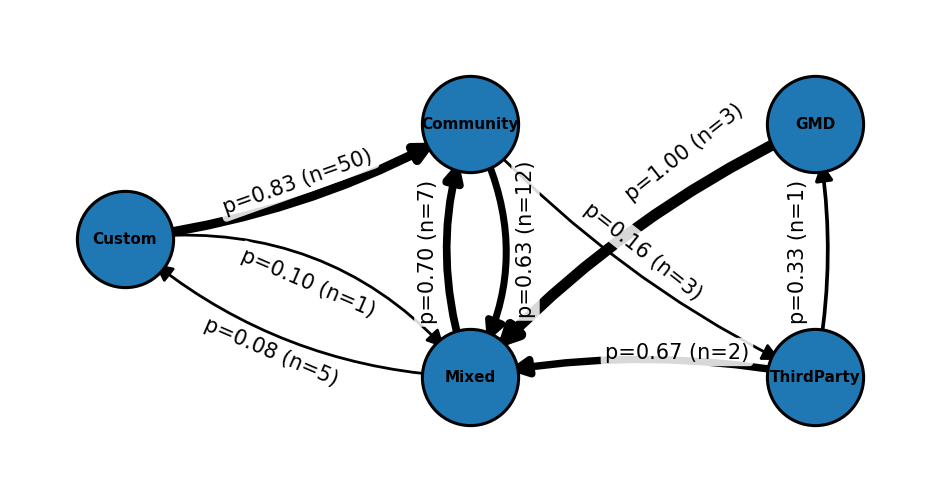

In [42]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import networkx as nx
except ImportError:
    raise SystemExit("Please install networkx (e.g., pip install networkx) to run this script.")

# -----------------------------
# Build graph from computed TOP2
# -----------------------------
G = nx.DiGraph()
G.add_nodes_from(NODES)

for src, edges in TOP2.items():
    for (tgt, p, n) in edges[:2]:
        if p <= 0 or src == tgt:
            continue
        G.add_edge(src, tgt, prob=float(p), count=int(n))

# -----------------------------
# Layout (fixed positions)
# -----------------------------
pos = {
    "Custom": (0.0, 0.0),
    "Community": (1.5, 0.5),
    "Mixed": (1.5, -0.6),
    "GMD": (3.0, 0.5),
    "ThirdParty": (3.0, -0.6),
}
if set(pos.keys()) != set(G.nodes):
    pos = nx.spring_layout(G, seed=7, k=1.0)

# -----------------------------
# Auto curvature for reciprocal pairs (parallel arcs on same side)
# -----------------------------
rad_map = {}
for (u, v) in G.edges:
    if G.has_edge(v, u) and (u, v) not in rad_map and (v, u) not in rad_map:
        rad_map[(u, v)] = -0.28
        rad_map[(v, u)] = -0.18

# -----------------------------
# Figure + padded axes so circles don't clip
# -----------------------------
plt.figure(figsize=(9.5, 5.4))
ax = plt.gca()
ax.set_aspect("equal", adjustable="box")
xs = [xy[0] for xy in pos.values()]
ys = [xy[1] for xy in pos.values()]
PAD_X, PAD_Y = 0.5, 0.5
ax.set_xlim(min(xs) - PAD_X, max(xs) + PAD_X)
ax.set_ylim(min(ys) - PAD_Y, max(ys) + PAD_Y)

# -----------------------------
# Draw edges (first)
# -----------------------------
edge_widths = {e: max(2.0, 8.0 * G[e[0]][e[1]]["prob"]) for e in G.edges}

# Route Custom <-> ThirdParty ABOVE Mixed (gentle arc, no clipping)
special_rad = {}
if G.has_edge("Custom", "ThirdParty"):
    special_rad[("Custom", "ThirdParty")] = +0.35   # left->right: + bends up
if G.has_edge("ThirdParty", "Custom"):
    special_rad[("ThirdParty", "Custom")] = -0.35   # right->left: - bends up


for (u, v) in G.edges:
    nx.draw_networkx_edges(
        G, pos,
        edgelist=[(u, v)],
        arrowstyle="-|>",
        arrowsize=26,
        width=edge_widths[(u, v)],
        connectionstyle=f"arc3,rad={special_rad.get((u, v), rad_map.get((u, v), 0.10))}",
        min_source_margin=20,
        min_target_margin=28,
    )

# Nodes + labels (NO "Community Action" anymore)
nx.draw_networkx_nodes(G, pos, node_size=4800, linewidths=2.2, edgecolors="black")
nx.draw_networkx_labels(G, pos, labels={n: n for n in G.nodes}, font_size=11, font_weight="bold")

# -----------------------------
# Manual edge labels with perpendicular offset + upright text
# -----------------------------
def annotate_edge_label(
    ax, p0, p1, text,
    t=0.5,
    off=0,
    dx=0, dy=0,
    xy=None,
    rot=None,
    follow=True,
    upright=True,          # ✅ keep readable (no upside-down)
    vertical_thresh=80,    # ✅ if |angle| >= this, force +90 (bottom->top)
    **kw
):
    x0, y0 = p0
    x1, y1 = p1

    # Base anchor point
    if xy is None:
        x = (1 - t) * x0 + t * x1
        y = (1 - t) * y0 + t * y1
    else:
        x, y = xy

    # Display-space vectors (for consistent point offsets)
    P0 = ax.transData.transform([x0, y0])
    P1 = ax.transData.transform([x1, y1])
    vx, vy = P1 - P0

    # Perpendicular offset direction
    nx_disp, ny_disp = -vy, vx
    norm = np.hypot(nx_disp, ny_disp)
    if norm == 0:
        perp_dx = perp_dy = 0.0
        angle = 0.0
    else:
        nx_disp /= norm
        ny_disp /= norm
        perp_dx = off * nx_disp
        perp_dy = off * ny_disp

        angle = np.degrees(np.arctan2(vy, vx))

        if upright:
            # wrap to (-180, 180]
            angle = (angle + 180) % 360 - 180

            # keep left-to-right readable: force into [-90, +90]
            if angle > 90:
                angle -= 180
            elif angle < -90:
                angle += 180

            # if it's basically vertical, force bottom->top (+90)
            if abs(angle) >= vertical_thresh:
                angle = 90

    # Rotation choice
    if rot is not None:
        angle_to_use = rot
    elif follow:
        angle_to_use = angle
    else:
        angle_to_use = 0

    dx_pts = perp_dx + dx
    dy_pts = perp_dy + dy

    ax.annotate(
        text,
        xy=(x, y),
        xytext=(dx_pts, dy_pts),
        textcoords="offset points",
        ha="center", va="center",
        rotation=angle_to_use,
        rotation_mode="anchor",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85),
        **kw,
    )


def edge_text(u, v):
    return f"p={G[u][v]['prob']:.2f} (n={G[u][v]['count']})"

# Optional: keep your custom placements (only applied if that edge exists)
placements = {
    ("Community", "Mixed"): {"t": 0.45, "off": 40},
    ("Mixed", "Community"): {"t": 0.50, "off": +30},

    ("Mixed", "ThirdParty"): {"t": 0.40, "off": -22},
    ("ThirdParty", "Mixed"): {"t": 0.40, "off": -18},

    ("Community", "GMD"): {"t": 0.58, "off": +6},
    ("GMD", "Mixed"): {"t": 0.28, "off": -40},

    ("Custom", "ThirdParty"): {"t": 0.52, "off": -100},


    ("ThirdParty", "GMD"): {"t": 0.50, "off": +12},
    ("GMD", "ThirdParty"): {"t": 0.55, "off": -22},

    ("Custom", "Mixed"): {"t": 0.48, "off": -36},
    ("Mixed", "Custom"): {"t": 0.50, "off": -20},
}


for (u, v) in G.edges:
    p0, p1 = pos[u], pos[v]
    spec = placements.get((u, v), {"t": 0.50, "off": 0, "dx": 0, "dy": 0})

    annotate_edge_label(
        ax, p0, p1, edge_text(u, v),
        t=spec["t"],
        off=spec["off"],     # <-- was offset_pts
        dx=spec.get("dx", 0),
        dy=spec.get("dy", 0),
        xy=spec.get("xy", None),
        rot=spec.get("rot", None),
        follow=spec.get("follow", True),
        fontsize=15,
    )


plt.axis("off")
plt.tight_layout()
plt.show()

# Optional save (rename to RQ2)
# plt.savefig("rq2_state_machine_top2.png", dpi=300, bbox_inches="tight")


In [ ]:
#stacked bar chart

[info] Using: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\2 - RQ2\Observations\List_Change_Episodes.csv
[ok] Wrote CSV: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\RQ2_Outputs\rq2_obs_time_buckets_stacked.csv
           Community  Custom   GMD  ThirdParty
bucket                                        
2011–2013       0.00  100.00  0.00        0.00
2014–2016       0.00  100.00  0.00        0.00
2017–2019       2.75   92.31  0.00        4.95
2020–2022      42.78   51.77  1.91        3.54
2023–2025      54.65   35.18  4.65        5.53
[ok] Wrote figure: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\RQ2_Outputs\rq2_obs_time_buckets_stacked.png


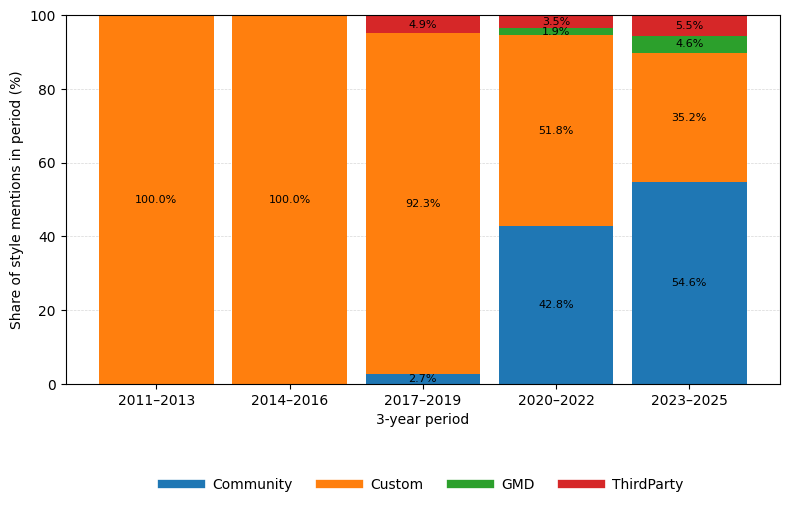

In [46]:
# === Stacked Bar — 3-year buckets (per-style union), using List_Change_Episodes.csv ===
# Reads from the same Step3 root location style as your other plot.

from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------- Paths (same pattern as your other plot) ----------
ROOT = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026")
OBS_DIR = ROOT / "2 - RQ2" / "Observations"
EP_CSV = OBS_DIR / "List_Change_Episodes.csv"

# if not EP_CSV.exists():
#     # fallback if the CSV is stored elsewhere under ROOT
#     hits = list(ROOT.rglob("List_Change_Episodes1.csv"))
#     if not hits:
#         raise FileNotFoundError(f"Could not find List_Change_Episodes.csv under {OBS_DIR} or {ROOT}")
#     hits.sort(key=lambda p: p.stat().st_mtime, reverse=True)
#     EP_CSV = hits[0]

OUT_DIR = ROOT / "RQ2_Outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PNG = OUT_DIR / "rq2_obs_time_buckets_stacked.png"
OUT_CSV = OUT_DIR / "rq2_obs_time_buckets_stacked.csv"

print("[info] Using:", EP_CSV)

# ---------- Settings ----------
CUTOFF_ISO   = "2025-08-10 23:59:59+00:00"
PERSIST_DAYS = 14.0

STYLES = ("Emu_Community", "Emu_Custom", "GMD", "ThirdParty")
DISPLAY_MAP = {
    "Emu_Community": "Community",
    "Emu_Custom":    "Custom",
    "GMD":           "GMD",
    "ThirdParty":    "ThirdParty",
}
DISPLAY_ORDER = [DISPLAY_MAP[s] for s in STYLES]

YEAR_START, YEAR_END, BUCKET_SIZE = 2008, 2025, 3

# ---------- Helpers ----------
def parse_styleset(cell: str) -> list[str]:
    s = str(cell).strip() if cell is not None else ""
    if not s:
        return []
    # normalize list-ish strings and split
    s = s.replace("[", "").replace("]", "").replace("'", "").replace('"', "")
    for sep in ("||", "+", ",", ";"):
        if sep in s:
            parts = [p.strip() for p in s.split(sep)]
            return [p for p in parts if p]
    return [s]

def bucket_label(year: int) -> str:
    k = (year - YEAR_START) // BUCKET_SIZE
    y0 = YEAR_START + k * BUCKET_SIZE
    y1 = min(y0 + BUCKET_SIZE - 1, YEAR_END)
    return f"{y0}–{y1}"

# ---------- Load episodes CSV ----------
ep = pd.read_csv(EP_CSV, dtype=str, keep_default_na=False, encoding="utf-8")

# expected columns in your file
repo_col  = "full_name" if "full_name" in ep.columns else "repo_name"
start_col = "episode_start_utc"
end_col   = "episode_end_utc"
style_col = "episode_styleset"

if start_col not in ep.columns or end_col not in ep.columns or style_col not in ep.columns:
    raise ValueError(f"Missing required columns in {EP_CSV.name} (need {start_col}, {end_col}, {style_col}).")

ep["_start"] = pd.to_datetime(ep[start_col], utc=True, errors="coerce")
ep["_end"]   = pd.to_datetime(ep[end_col], utc=True, errors="coerce")
ep = ep[pd.notna(ep["_start"]) & pd.notna(ep["_end"]) & (ep["_end"] > ep["_start"])].copy()

# Apply the "removed-only" persistence rule (keep >=14d OR active at cutoff)
dur = pd.to_numeric(ep.get("episode_duration_days", ""), errors="coerce")
active = ep.get("is_active_at_cutoff", "").astype(str).str.strip().str.lower().isin({"true","1","yes","y","t"})
ep = ep[(dur >= PERSIST_DAYS) | active].copy()

ep["_styles"] = ep[style_col].apply(parse_styleset)
ep["_styles"] = ep["_styles"].apply(lambda xs: sorted(set([x for x in xs if x in STYLES])))

# ---------- Build month-level activity (repo-month style union) ----------
rows = []
for _, r in ep.iterrows():
    styles = set(r["_styles"])
    if not styles:
        continue

    start = r["_start"]
    end = r["_end"]
    end_incl = end - pd.Timedelta(microseconds=1)

    first = pd.Timestamp(start.year, start.month, 1, tz="UTC")
    last  = pd.Timestamp(end_incl.year, end_incl.month, 1, tz="UTC")

    months = pd.date_range(first, last, freq="MS", tz="UTC")
    for m in months:
        row = {"repo_name": r[repo_col], "month": m}
        for sty in STYLES:
            row[sty] = 1 if sty in styles else 0
        rows.append(row)

dfm = pd.DataFrame(rows)
dfm = dfm.groupby(["repo_name", "month"], as_index=False)[list(STYLES)].max()

dfm["bucket"] = dfm["month"].dt.year.map(bucket_label)

# per bucket: count repos that mention each style at least once in that bucket (union per repo)
style_bucket_counts = (
    dfm.groupby(["bucket", "repo_name"])[list(STYLES)]
       .max()
       .reset_index()
       .groupby("bucket")[list(STYLES)]
       .sum()
       .sort_index()
)

# Convert to shares: each bucket sums to 100 across styles
tot_mentions = style_bucket_counts.sum(axis=1).replace(0, np.nan)
style_bucket_shares = (style_bucket_counts.T / tot_mentions).T.fillna(0.0) * 100.0
style_bucket_shares = style_bucket_shares.rename(columns=DISPLAY_MAP)
style_bucket_shares = style_bucket_shares[[c for c in DISPLAY_ORDER if c in style_bucket_shares.columns]]

style_bucket_shares.to_csv(OUT_CSV, encoding="utf-8")
print(f"[ok] Wrote CSV: {OUT_CSV}")
print(style_bucket_shares.round(2))

# ---------- Plot (stacked bar) ----------
fig, ax = plt.subplots(figsize=(8, 5))
style_bucket_shares.plot(kind="bar", stacked=True, ax=ax, width=0.86, edgecolor="none")

ax.set_xlabel("3-year period")
ax.set_ylabel("Share of style mentions in period (%)")
ax.set_ylim(0, 100)
ax.set_xticklabels(style_bucket_shares.index.tolist(), rotation=0, ha="center")
ax.margins(x=0.015, y=0)
ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)

# Legend proxies with exact bar colors
bar_containers = [c for c in ax.containers if hasattr(c, "patches") and c.patches]
legend_labels = style_bucket_shares.columns.tolist()
colors = [bc.patches[0].get_facecolor() for bc in bar_containers[:len(legend_labels)]]
proxies = [Line2D([0], [0], color=c, lw=6) for c in colors]

leg = ax.get_legend()
if leg is not None:
    leg.remove()
ax.legend(proxies, legend_labels, loc="upper center", bbox_to_anchor=(0.5, -0.22),
          ncol=len(legend_labels), frameon=False, handlelength=2.8)

# On-bar percent labels (less decimals for readability)
for i, bucket in enumerate(style_bucket_shares.index):
    cum = 0.0
    for sty in legend_labels:
        val = float(style_bucket_shares.loc[bucket, sty])
        if val <= 0.0:
            continue
        ax.text(i, cum + val/2.0, f"{val:.1f}%", ha="center", va="center", fontsize=8)
        cum += val

plt.subplots_adjust(bottom=.3)
plt.tight_layout()

plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
print(f"[ok] Wrote figure: {OUT_PNG}")

plt.show()
